Авиационные двигатели подвергаются постоянной деградации. Внеплановый выход из строя обходится значительно дороже, чем плановое техническое обслуживание.

Цель: Предсказать вероятность поломки двигателя в ближайшие 30 циклов, чтобы заблаговременно направить двигатель на плановый ремонт и минимизировать затраты на аварийное обслуживание.


**NASA C-MAPSS (Commercial Modular Aero-Propulsion System Simulation)** — симуляция деградации авиационных двигателей.



In [2]:
!pip install -q kagglehub optuna shap gradio xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.1 MB/s eta 0:00:00


In [3]:
import torch
import subprocess

# ─────────────────────────────────────────────
# Проверка доступности GPU
# ─────────────────────────────────────────────
if torch.cuda.is_available():
    device = torch.device('cuda')
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'✅ GPU доступен: {gpu_name}')
    print(f'   Видеопамять : {gpu_mem:.1f} GB')
    # Дополнительно смотрим вывод nvidia-smi
    result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total,driver_version',
                             '--format=csv,noheader'], capture_output=True, text=True)
    if result.returncode == 0:
        print(f'   nvidia-smi  : {result.stdout.strip()}')
else:
    device = torch.device('cpu')
    print('⚠️  GPU недоступен — используется CPU.')
    print('   Для активации GPU: Runtime → Change runtime type → GPU')

print(f'\n🔧 Используемое устройство для PyTorch: {device}')

✅ GPU доступен: Tesla T4
   Видеопамять : 14.6 GB
   nvidia-smi  : Tesla T4, 15360 MiB, 580.82.07

🔧 Используемое устройство для PyTorch: cuda


In [4]:
import kagglehub
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print('📥 Скачивание датасета bishals098/nasa-turbofan-engine-degradation-simulation...')
dataset_path = kagglehub.dataset_download(
    'bishals098/nasa-turbofan-engine-degradation-simulation'
)
print(f'✅ Датасет загружен в: {dataset_path}')
print('\n Содержимое директории:')
for f in sorted(os.listdir(dataset_path)):
    size = os.path.getsize(os.path.join(dataset_path, f))
    print(f'   {f:40s} {size/1024:.1f} KB')

📥 Скачивание датасета bishals098/nasa-turbofan-engine-degradation-simulation...


100%|██████████| 12.3M/12.3M [00:00<00:00, 94.0MB/s]

Extracting files...


✅ Датасет загружен в: /root/.cache/kagglehub/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/versions/1

 Содержимое директории:
   Damage Propagation Modeling.pdf          424.0 KB
   RUL_FD001.txt                            0.4 KB
   RUL_FD002.txt                            1.1 KB
   RUL_FD003.txt                            0.4 KB
   RUL_FD004.txt                            1.1 KB
   readme.txt                               2.4 KB
   test_FD001.txt                           2176.6 KB
   test_FD002.txt                           5600.2 KB
   test_FD003.txt                           2760.4 KB
   test_FD004.txt                           6794.7 KB
   train_FD001.txt                          3433.0 KB
   train_FD002.txt                          8869.6 KB
   train_FD003.txt                          4115.1 KB
   train_FD004.txt                          10108.1 KB


In [5]:
# ─────────────────────────────────────────────
# Определяем имена столбцов согласно спецификации C-MAPSS
# ─────────────────────────────────────────────
column_names = (
    ['unit_number', 'time_cycle']           # ID двигателя и номер цикла
    + [f'setting_{i}' for i in range(1, 4)] # 3 операционные настройки
    + [f'sensor_{i}' for i in range(1, 22)] # 21 датчик
)
print(f'Всего столбцов: {len(column_names)}')
print('Первые 10:', column_names[:10])

# ─────────────────────────────────────────────
# Загрузка обучающей и тестовой выборок
#    Файлы разделены пробелами, без заголовков
# ─────────────────────────────────────────────
def load_cmapss(path, filename):
    """Загружает файл C-MAPSS и возвращает DataFrame с именованными столбцами."""
    filepath = os.path.join(path, filename)
    df = pd.read_csv(
        filepath,
        sep=r'\s+',          # разделитель — один или несколько пробелов
        header=None,          # нет строки заголовка
        names=column_names,   # задаём имена вручную
        index_col=False
    )
    # Удаляем возможные полностью пустые столбцы (артефакт trailing spaces)
    df = df.dropna(axis=1, how='all')
    return df

train_df = load_cmapss(dataset_path, 'train_FD001.txt')
test_df  = load_cmapss(dataset_path, 'test_FD001.txt')

# Загружаем истинные RUL для тестовой выборки (один столбец, без заголовка)
rul_test = pd.read_csv(
    os.path.join(dataset_path, 'RUL_FD001.txt'),
    header=None, names=['RUL']
)

print(f'\n Train shape : {train_df.shape}')
print(f' Test shape  : {test_df.shape}')
print(f' RUL labels  : {rul_test.shape}')
train_df.head(3)

Всего столбцов: 26
Первые 10: ['unit_number', 'time_cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5']

 Train shape : (20631, 26)
 Test shape  : (13096, 26)
 RUL labels  : (100, 1)


,unit_number,time_cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442


In [6]:
# ─────────────────────────────────────────────
# Очистка: удаляем константные столбцы
# ─────────────────────────────────────────────
# Считаем стандартное отклонение по каждому столбцу в тренировочных данных
std_series = train_df.std(numeric_only=True)
constant_cols = std_series[std_series < 1e-6].index.tolist()

train_df = train_df.drop(columns=constant_cols)
test_df  = test_df.drop(columns=constant_cols)

# Список рабочих датчиков после очистки
sensor_cols = [c for c in train_df.columns if c.startswith('sensor_')]
setting_cols = [c for c in train_df.columns if c.startswith('setting_')]

print(f'\nРабочих датчиков: {len(sensor_cols)} -> {sensor_cols}')
print(f'Настроек        : {len(setting_cols)} -> {setting_cols}')
print(f'\nТренировочная выборка после очистки: {train_df.shape}')


Рабочих датчиков: 15 -> ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Настроек        : 2 -> ['setting_1', 'setting_2']

Тренировочная выборка после очистки: (20631, 19)


In [7]:
# ─────────────────────────────────────────────
#    RUL = max_cycle_for_engine - current_cycle
# ─────────────────────────────────────────────
max_cycles = train_df.groupby('unit_number')['time_cycle'].max().rename('max_cycle')
train_df = train_df.merge(max_cycles, on='unit_number')
train_df['RUL']    = train_df['max_cycle'] - train_df['time_cycle']
train_df = train_df.drop(columns=['max_cycle'])

FAILURE_WINDOW = 30  # горизонт предсказания в циклах
train_df['target'] = (train_df['RUL'] <= FAILURE_WINDOW).astype(int)

positive_rate = train_df['target'].mean() * 100
print(f'   RUL min/max : {train_df["RUL"].min()} / {train_df["RUL"].max()}')
print(f'   RUL mean    : {train_df["RUL"].mean():.1f} циклов')
print(f'\nДоля класса 1 (поломка близко): {positive_rate:.1f}%')

   RUL min/max : 0 / 361
   RUL mean    : 107.8 циклов

Доля класса 1 (поломка близко): 15.0%


Визуализируем двигатель #52 (жизнь: 213 циклов, RUL max=212)
Топ-3 датчика по |корр. с RUL|: ['sensor_11', 'sensor_4', 'sensor_12']
  sensor_11: r = -0.696
  sensor_4: r = -0.679
  sensor_12: r = 0.672


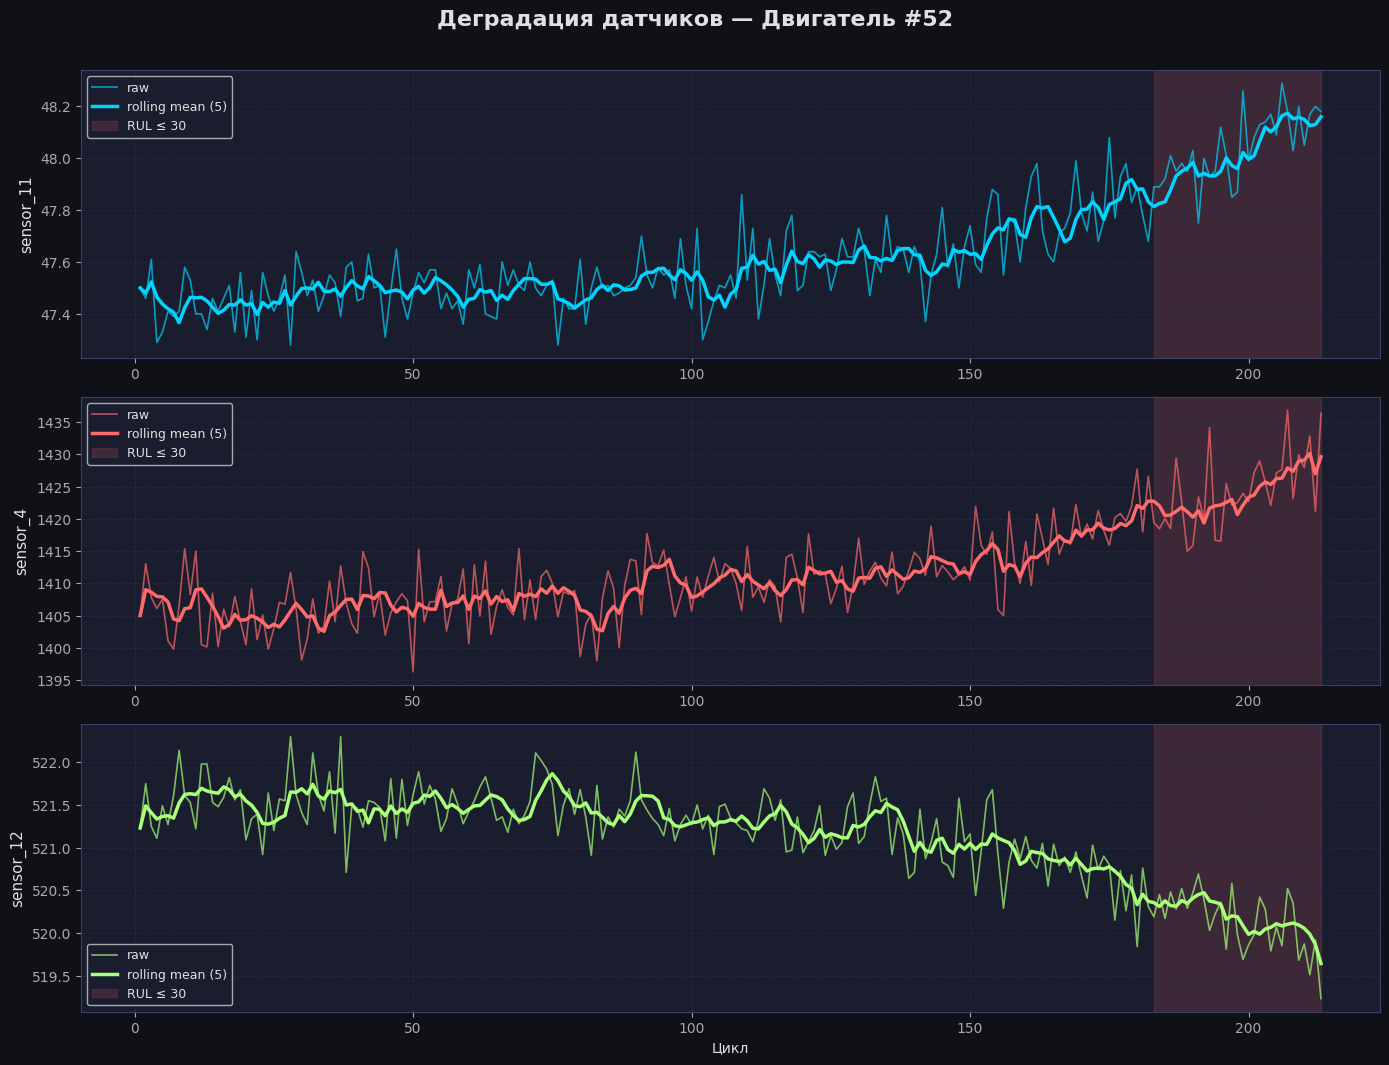

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# ─────────────────────────────────────────────
# Глобальный стиль графиков
# ─────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0F1117',
    'axes.facecolor'  : '#1A1D2E',
    'axes.edgecolor'  : '#3D4066',
    'axes.labelcolor' : '#E0E0E0',
    'xtick.color'     : '#AAAAAA',
    'ytick.color'     : '#AAAAAA',
    'text.color'      : '#E0E0E0',
    'grid.color'      : '#2D3052',
    'grid.linestyle'  : '--',
    'grid.alpha'      : 0.5,
    'font.family'     : 'DejaVu Sans'
})
PALETTE = ['#00D4FF', '#FF6B6B', '#A8FF78', '#FFB347', '#C779D0']

# ─────────────────────────────────────────────
# Выбираем случайный двигатель для визуализации
# ─────────────────────────────────────────────
np.random.seed(42)
sample_unit = np.random.choice(train_df['unit_number'].unique())
engine_data = train_df[train_df['unit_number'] == sample_unit].copy()
print(f'Визуализируем двигатель #{sample_unit} '
      f'(жизнь: {len(engine_data)} циклов, '
      f'RUL max={engine_data["RUL"].max()})')


corr_with_rul = train_df[sensor_cols + ['RUL']].corr()['RUL'].drop('RUL')
top3_sensors = corr_with_rul.abs().nlargest(3).index.tolist()
print(f'Топ-3 датчика по |корр. с RUL|: {top3_sensors}')
for s in top3_sensors:
    print(f'  {s}: r = {corr_with_rul[s]:.3f}')

# ─────────────────────────────────────────────
# График 1: Деградация ключевых датчиков
# ─────────────────────────────────────────────
fig, axes = plt.subplots(len(top3_sensors), 1, figsize=(14, 3.5 * len(top3_sensors)))
fig.suptitle(f'Деградация датчиков — Двигатель #{sample_unit}',
             fontsize=16, fontweight='bold', y=1.01)

for ax, sensor, color in zip(axes, top3_sensors, PALETTE):
    ax.plot(engine_data['time_cycle'], engine_data[sensor],
            color=color, linewidth=1.2, alpha=0.7, label='raw')
    # Скользящее среднее для наглядности тренда
    smoothed = engine_data[sensor].rolling(5, min_periods=1).mean()
    ax.plot(engine_data['time_cycle'], smoothed,
            color=color, linewidth=2.5, label='rolling mean (5)')
    # Зона «опасности» (RUL <= 30)
    danger_start = engine_data['time_cycle'].max() - FAILURE_WINDOW
    ax.axvspan(danger_start, engine_data['time_cycle'].max(),
               alpha=0.15, color='#FF6B6B', label=f'RUL ≤ {FAILURE_WINDOW}')
    ax.set_ylabel(sensor, fontsize=11)
    ax.set_xlabel('Цикл' if sensor == top3_sensors[-1] else '')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True)

plt.tight_layout()
plt.savefig('sensor_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

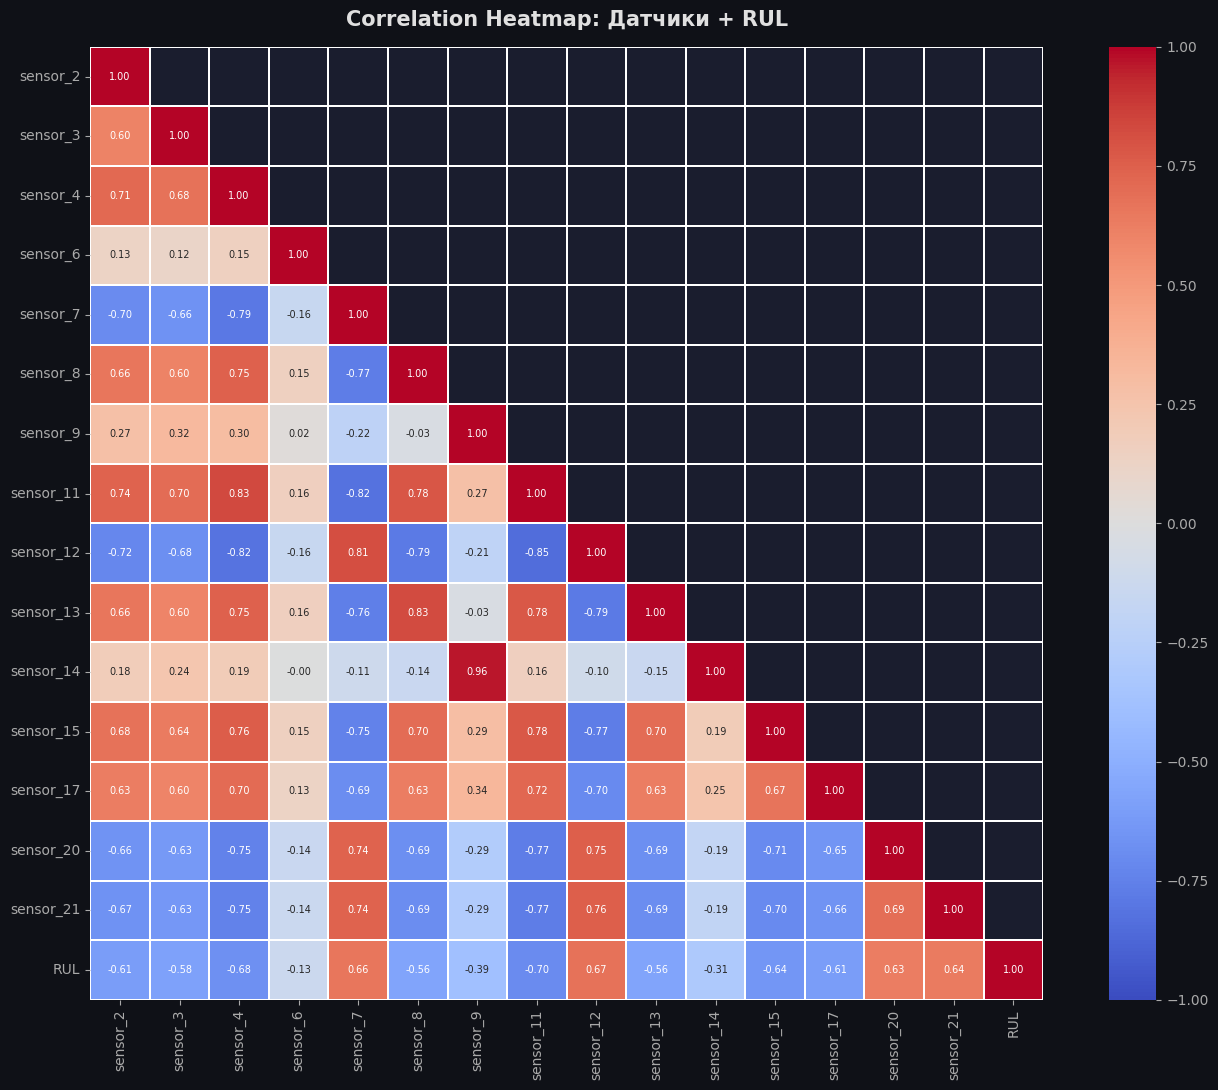

In [9]:
# ─────────────────────────────────────────────
# График 2: Тепловая карта корреляций
# ─────────────────────────────────────────────
# Используем корреляцию Пирсона между датчиками и RUL
corr_matrix = train_df[sensor_cols + ['RUL']].corr()

fig, ax = plt.subplots(figsize=(14, 11))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # верхний треугольник
sns.heatmap(
    corr_matrix,
    ax=ax,
    mask=mask,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    annot=True, fmt='.2f',
    annot_kws={'size': 7},
    linewidths=0.3,
    square=True
)
ax.set_title('Correlation Heatmap: Датчики + RUL', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
WINDOW = 5  # окно скользящего среднего в циклах

def add_rolling_features(df, sensors, window=5):
    df = df.copy()
    for sensor in sensors:
        grouped = df.groupby('unit_number')[sensor]
        df[f'{sensor}_rmean'] = grouped.transform(
            lambda x: x.rolling(window, min_periods=window).mean()
        )
        df[f'{sensor}_rstd'] = grouped.transform(
            lambda x: x.rolling(window, min_periods=window).std()
        )
    return df

train_df = add_rolling_features(train_df, sensor_cols, window=WINDOW)
test_df  = add_rolling_features(test_df,  sensor_cols, window=WINDOW)

train_df = train_df.dropna().reset_index(drop=True)
test_df  = test_df.dropna().reset_index(drop=True)

exclude_cols = {'unit_number', 'time_cycle', 'RUL', 'target'}
feature_cols = [c for c in train_df.columns if c not in exclude_cols]

print(f'Признаков после Feature Engineering: {len(feature_cols)}')
print(f'   Оригинальные датчики        : {len(sensor_cols)}')
print(f'   Rolling mean + Rolling std  : {len(sensor_cols) * 2}')
print(f'   Настройки                   : {len(setting_cols)}')
print(f'\n Train после dropna: {train_df.shape}')
print(f' Test  после dropna: {test_df.shape}')

Признаков после Feature Engineering: 47
   Оригинальные датчики        : 15
   Rolling mean + Rolling std  : 30
   Настройки                   : 2

 Train после dropna: (20231, 51)
 Test  после dropna: (12696, 49)


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             classification_report)

# ─────────────────────────────────────────────
# 1. Подготовка тестовых меток
#    RUL_FD001.txt содержит RUL для последнего цикла каждого двигателя
# ─────────────────────────────────────────────
# Присваиваем RUL каждому двигателю тестовой выборки
test_units = test_df['unit_number'].unique()
assert len(test_units) == len(rul_test), \
    f'Число двигателей в тесте ({len(test_units)}) ≠ числу RUL ({len(rul_test)})'

# Создаём словарь unit -> RUL
rul_map = dict(zip(sorted(test_units), rul_test['RUL'].values))

# Для каждой строки теста вычисляем RUL:
# RUL последнего цикла двигателя = из RUL_FD001
# RUL предыдущего цикла = RUL_последнего + (max_cycle - current_cycle)
test_max = test_df.groupby('unit_number')['time_cycle'].max()
test_df['RUL'] = test_df.apply(
    lambda r: rul_map[r['unit_number']] + (test_max[r['unit_number']] - r['time_cycle']),
    axis=1
)
test_df['target'] = (test_df['RUL'] <= FAILURE_WINDOW).astype(int)

print(f'✅ Тестовые метки готовы.')
print(f'   Класс 1 (поломка) в тесте: {test_df["target"].mean()*100:.1f}%')

# ─────────────────────────────────────────────
# 2. Масштабирование признаков для обеих моделей
# ─────────────────────────────────────────────
X_train = train_df[feature_cols].values
y_train = train_df['target'].values
X_test  = test_df[feature_cols].values
y_test  = test_df['target'].values

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit только на трейне!
X_test_sc  = scaler.transform(X_test)

print(f'\nX_train: {X_train_sc.shape}, y_train: {y_train.shape}')
print(f'X_test : {X_test_sc.shape},  y_test : {y_test.shape}')

✅ Тестовые метки готовы.
   Класс 1 (поломка) в тесте: 2.6%

X_train: (20231, 47), y_train: (20231,)
X_test : (12696, 47),  y_test : (12696,)


In [12]:
from xgboost import XGBClassifier

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count
print(f'Дисбаланс: neg={neg_count}, pos={pos_count}, weight={scale_weight:.2f}')

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,  # балансировка классов scale_pos_weight — компенсация дисбаланса классов
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(
    X_train_sc, y_train,
    eval_set=[(X_test_sc, y_test)],
    verbose=False
)


def evaluate_model(name, y_true, y_pred, y_prob):
    metrics = {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_true, y_prob)
    }
    print(f'\n{"─"*45}')
    print(f'  {name}')
    print(f'{"─"*45}')
    for k, v in metrics.items():
        print(f'  {k:12s}: {v:.4f} ')
    return metrics

xgb_pred = xgb_model.predict(X_test_sc)
xgb_prob = xgb_model.predict_proba(X_test_sc)[:, 1]
xgb_metrics = evaluate_model('XGBoost (базовый)', y_test, xgb_pred, xgb_prob)

Дисбаланс: neg=17131, pos=3100, weight=5.53

─────────────────────────────────────────────
  XGBoost (базовый)
─────────────────────────────────────────────
  Accuracy    : 0.9839 
  Precision   : 0.6954 
  Recall      : 0.6807 
  F1-Score    : 0.6880 
  ROC-AUC     : 0.9881 


In [13]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ─────────────────────────────────────────────
# Подготовка 3D-тензоров для LSTM
# Формат: (samples, timesteps, features)
# Для каждого момента времени берём последние SEQ_LEN циклов
# ─────────────────────────────────────────────
SEQ_LEN = 30  # длина временного окна (циклов истории)

def create_sequences(df, feature_cols, target_col, seq_len):
    """
    Создаёт 3D-тензор для LSTM:
    - Для каждого двигателя скользим окном seq_len по времени
    - Target = метка на последнем шаге окна
    """
    X_list, y_list = [], []
    for unit in df['unit_number'].unique():
        unit_df = df[df['unit_number'] == unit].sort_values('time_cycle')
        feats  = unit_df[feature_cols].values
        labels = unit_df[target_col].values
        # Скользящее окно
        for i in range(seq_len, len(feats)):
            X_list.append(feats[i - seq_len:i])  # (seq_len, n_features)
            y_list.append(labels[i])              # скалярная метка
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

print(f'⚙️  Создаём последовательности (SEQ_LEN={SEQ_LEN})...')

# Добавляем колонку target в test_df перед вызовом функции
X_train_seq, y_train_seq = create_sequences(
    train_df, feature_cols, 'target', SEQ_LEN
)
X_test_seq, y_test_seq = create_sequences(
    test_df, feature_cols, 'target', SEQ_LEN
)

print(f'✅ X_train_seq: {X_train_seq.shape}  (samples, timesteps, features)')
print(f'✅ X_test_seq : {X_test_seq.shape}')

# ─────────────────────────────────────────────
# Нормализация: scaler уже обучен на 2D,
# применяем его к 3D, временно reshape
# ─────────────────────────────────────────────
n_train, ts, nf = X_train_seq.shape
n_test = X_test_seq.shape[0]

X_train_seq_sc = scaler.transform(
    X_train_seq.reshape(-1, nf)
).reshape(n_train, ts, nf).astype(np.float32)

X_test_seq_sc = scaler.transform(
    X_test_seq.reshape(-1, nf)
).reshape(n_test, ts, nf).astype(np.float32)

# ─────────────────────────────────────────────
# PyTorch DataLoaders
# ─────────────────────────────────────────────
BATCH_SIZE = 256

train_dataset = TensorDataset(
    torch.tensor(X_train_seq_sc),
    torch.tensor(y_train_seq)
)
test_dataset  = TensorDataset(
    torch.tensor(X_test_seq_sc),
    torch.tensor(y_test_seq)
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'\n✅ DataLoaders готовы. Батчей в трейне: {len(train_loader)}')

⚙️  Создаём последовательности (SEQ_LEN=30)...
✅ X_train_seq: (17231, 30, 47)  (samples, timesteps, features)
✅ X_test_seq : (9699, 30, 47)

✅ DataLoaders готовы. Батчей в трейне: 68


In [14]:
# ─────────────────────────────────────────────
# Архитектура LSTM
# ─────────────────────────────────────────────
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,          # (batch, seq, feature)
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, 1)           # один выход: логит вероятности класса 1
        )

    def forward(self, x):
        # lstm_out: (batch, seq_len, hidden_size)
        lstm_out, _ = self.lstm(x)
        # Берём только выход на последнем временном шаге
        last_out = self.dropout(lstm_out[:, -1, :])
        logit = self.fc(last_out)
        return logit.squeeze(1)        # (batch,)


n_features = X_train_seq_sc.shape[2]
lstm_model = LSTMClassifier(
    input_size=n_features,
    hidden_size=128,
    num_layers=2,
    dropout=0.3
).to(device)

print('Архитектура LSTM:')
print(lstm_model)

total_params = sum(p.numel() for p in lstm_model.parameters())
print(f'\nВсего параметров: {total_params:,}')
print(f'Устройство      : {next(lstm_model.parameters()).device}')

Архитектура LSTM:
LSTMClassifier(
  (lstm): LSTM(47, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.15, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

Всего параметров: 231,041
Устройство      : cuda:0


⚙️  Обучаем LSTM на cuda (20 эпох)...
  Epoch   1/20 | Train Loss: 0.4958 | Val Loss: 0.1572 | LR: 0.001000
  Epoch   5/20 | Train Loss: 0.0570 | Val Loss: 0.2835 | LR: 0.000500
  Epoch  10/20 | Train Loss: 0.0196 | Val Loss: 0.4904 | LR: 0.000250
  Epoch  15/20 | Train Loss: 0.0094 | Val Loss: 0.6014 | LR: 0.000125
  Epoch  20/20 | Train Loss: 0.0048 | Val Loss: 0.7407 | LR: 0.000063


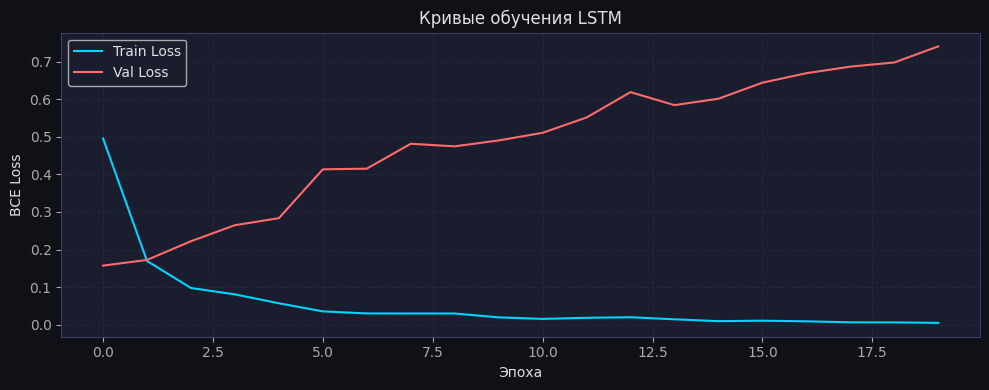

In [15]:
# ─────────────────────────────────────────────
# Обучение LSTM
# ─────────────────────────────────────────────
EPOCHS    = 20
LR        = 1e-3

# BCEWithLogitsLoss = Sigmoid + BinaryCrossEntropy (численно стабильнее)
pos_w = torch.tensor([scale_weight], device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

history = {'train_loss': [], 'val_loss': []}

print(f'⚙️  Обучаем LSTM на {device} ({EPOCHS} эпох)...')
for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    lstm_model.train()
    train_losses = []
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = lstm_model(Xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)  # gradient clip
        optimizer.step()
        train_losses.append(loss.item())

    # ── Validation ──
    lstm_model.eval()
    val_losses = []
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = lstm_model(Xb)
            val_losses.append(criterion(logits, yb).item())

    tl = np.mean(train_losses)
    vl = np.mean(val_losses)
    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    scheduler.step(vl)

    if epoch % 5 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'  Epoch {epoch:3d}/{EPOCHS} | '
              f'Train Loss: {tl:.4f} | Val Loss: {vl:.4f} | LR: {lr_now:.6f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train_loss'], label='Train Loss', color=PALETTE[0])
ax.plot(history['val_loss'],   label='Val Loss',   color=PALETTE[1])
ax.set(xlabel='Эпоха', ylabel='BCE Loss', title='Кривые обучения LSTM')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ─────────────────────────────────────────────
# Оценка LSTM на тестовой выборке
# ─────────────────────────────────────────────
lstm_model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        logits = lstm_model(Xb)
        probs  = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(yb.numpy())

lstm_prob = np.array(all_probs)
lstm_pred = (lstm_prob >= 0.5).astype(int)
lstm_true = np.array(all_labels).astype(int)

lstm_metrics = evaluate_model('LSTM (PyTorch)', lstm_true, lstm_pred, lstm_prob)

# ─────────────────────────────────────────────
# Сводная таблица сравнения моделей
# ─────────────────────────────────────────────
comparison_df = pd.DataFrame({
    'XGBoost' : xgb_metrics,
    'LSTM'    : lstm_metrics
}).round(4)
print(comparison_df.to_string())



─────────────────────────────────────────────
  LSTM (PyTorch)
─────────────────────────────────────────────
  Accuracy    : 0.9786 
  Precision   : 0.7153 
  Recall      : 0.6205 
  F1-Score    : 0.6645 
  ROC-AUC     : 0.9829 
           XGBoost    LSTM
Accuracy    0.9839  0.9786
Precision   0.6954  0.7153
Recall      0.6807  0.6205
F1-Score    0.6880  0.6645
ROC-AUC     0.9881  0.9829


In [17]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Подавляем информационные сообщения Optuna (оставляем только предупреждения)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ─────────────────────────────────────────────
# Функция-objective: принимает trial, возвращает значение метрики
# ─────────────────────────────────────────────
def objective(trial):
    """Целевая функция Optuna: максимизировать Recall на CV."""
    params = {
        # Гиперпараметры, которые Optuna будет подбирать
        'max_depth'       : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 600, step=50),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma'           : trial.suggest_float('gamma', 0.0, 1.0),
        # Фиксированные параметры
        'scale_pos_weight': scale_weight,
        'eval_metric'     : 'logloss',
        'random_state'    : 42,
        'n_jobs'          : -1,
        'verbosity'       : 0
    }

    model = XGBClassifier(**params)

    # Stratified K-Fold: сохраняет пропорцию классов в каждом фолде
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(
        model, X_train_sc, y_train,
        cv=cv,
        scoring='recall',
        n_jobs=-1
    )
    return scores.mean()


N_TRIALS = 40

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'   Лучший Recall: {study.best_value:.4f}')
print(f'   Лучшие гиперпараметры:')
for k, v in study.best_params.items():
    print(f'     {k:25s}: {v}')

  0%|          | 0/40 [00:00<?, ?it/s]

   Лучший Recall: 0.9603
   Лучшие гиперпараметры:
     max_depth                : 3
     learning_rate            : 0.016387952971204225
     n_estimators             : 300
     subsample                : 0.7035202510081895
     colsample_bytree         : 0.875869770084707
     min_child_weight         : 4
     gamma                    : 0.8359868928857551



─────────────────────────────────────────────
  XGBoost (Optuna-tuned)
─────────────────────────────────────────────
  Accuracy    : 0.9777 
  Precision   : 0.5481 
  Recall      : 0.8404 
  F1-Score    : 0.6635 
  ROC-AUC     : 0.9905 


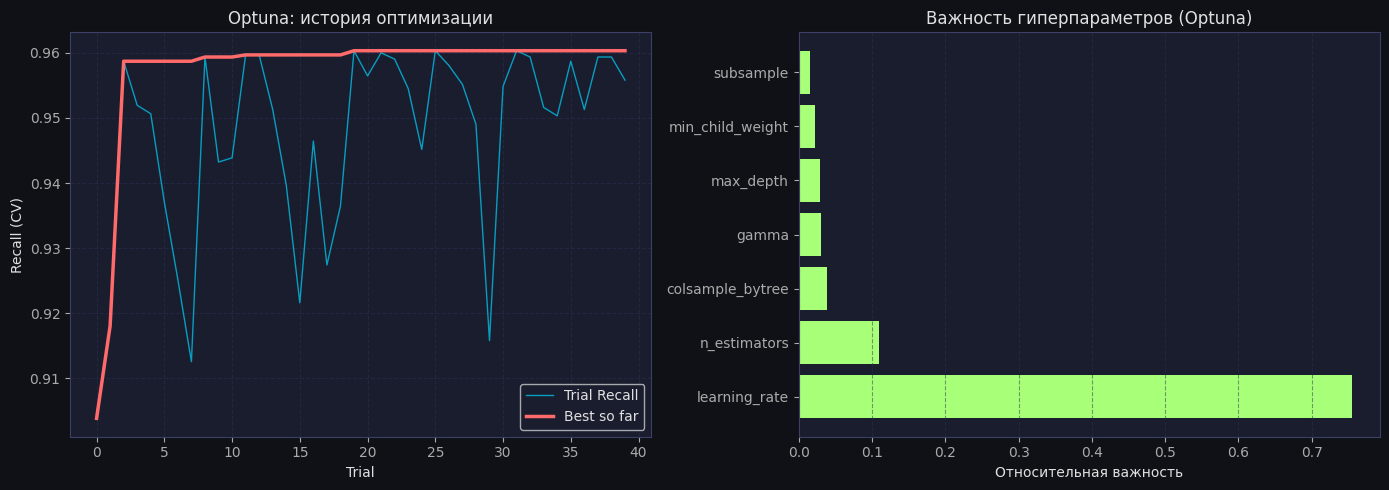


════════════════════════════════════════════════════════════
  ПОЛНОЕ СРАВНЕНИЕ: XGBoost base / LSTM / XGBoost tuned
════════════════════════════════════════════════════════════
           XGBoost (base)    LSTM  XGBoost (tuned)
Accuracy           0.9839  0.9786           0.9777
Precision          0.6954  0.7153           0.5481
Recall             0.6807  0.6205           0.8404
F1-Score           0.6880  0.6645           0.6635
ROC-AUC            0.9881  0.9829           0.9905
════════════════════════════════════════════════════════════


In [18]:
# ─────────────────────────────────────────────
# Обучаем финальный XGBoost с лучшими параметрами
# ─────────────────────────────────────────────
best_params = study.best_params.copy()
best_params.update({
    'scale_pos_weight': scale_weight,
    'eval_metric'     : 'logloss',
    'random_state'    : 42,
    'n_jobs'          : -1,
    'verbosity'       : 0
})

xgb_tuned = XGBClassifier(**best_params)
xgb_tuned.fit(X_train_sc, y_train)

tuned_pred = xgb_tuned.predict(X_test_sc)
tuned_prob = xgb_tuned.predict_proba(X_test_sc)[:, 1]
tuned_metrics = evaluate_model('XGBoost (Optuna-tuned)', y_test, tuned_pred, tuned_prob)

# ─── График Optuna: история оптимизации ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# История значений Recall по триалам
trial_values = [t.value for t in study.trials]
axes[0].plot(trial_values, color=PALETTE[0], alpha=0.7, linewidth=1, label='Trial Recall')
best_so_far = pd.Series(trial_values).cummax()
axes[0].plot(best_so_far, color=PALETTE[1], linewidth=2.5, label='Best so far')
axes[0].set(xlabel='Trial', ylabel='Recall (CV)', title='Optuna: история оптимизации')
axes[0].legend()
axes[0].grid(True)

# Важность гиперпараметров (через Optuna)
importances = optuna.importance.get_param_importances(study)
params_sorted = list(importances.keys())
values_sorted = [importances[k] for k in params_sorted]
axes[1].barh(params_sorted, values_sorted, color=PALETTE[2])
axes[1].set(xlabel='Относительная важность', title='Важность гиперпараметров (Optuna)')
axes[1].grid(True, axis='x')

plt.tight_layout()
plt.savefig('optuna_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Итоговое сравнение всех трёх моделей ───
print('\n' + '═'*60)
print('  ПОЛНОЕ СРАВНЕНИЕ: XGBoost base / LSTM / XGBoost tuned')
print('═'*60)
full_comparison = pd.DataFrame({
    'XGBoost (base)' : xgb_metrics,
    'LSTM'           : lstm_metrics,
    'XGBoost (tuned)': tuned_metrics
}).round(4)
print(full_comparison.to_string())
print('═'*60)

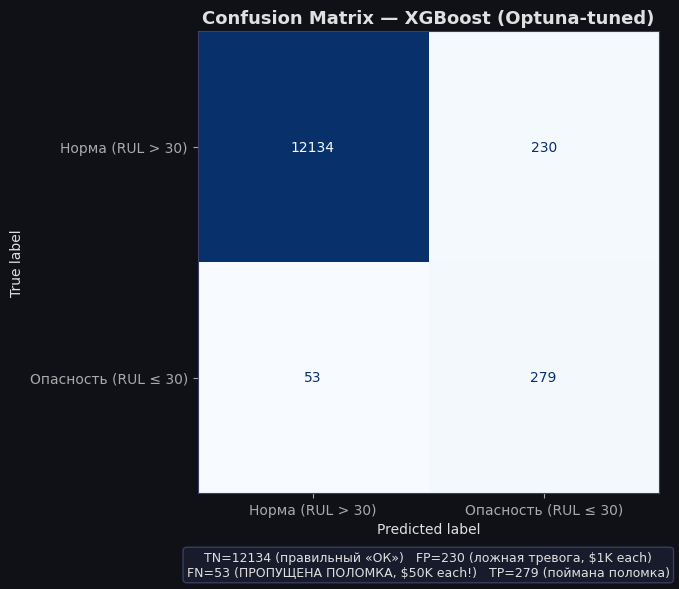

TP=279, TN=12134, FP=230, FN=53


In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ─────────────────────────────────────────────
# Confusion Matrix для лучшей модели (XGBoost tuned)
# ─────────────────────────────────────────────
cm = confusion_matrix(y_test, tuned_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Норма (RUL > 30)', 'Опасность (RUL ≤ 30)']
)
disp.plot(
    ax=ax,
    cmap='Blues',
    colorbar=False,
    values_format='d'
)
ax.set_title('Confusion Matrix — XGBoost (Optuna-tuned)', fontsize=13, fontweight='bold')

# Добавляем аннотацию с бизнес-смыслом
tn, fp, fn, tp = cm.ravel()
ax.text(0.5, -0.18,
        f'TN={tn} (правильный «ОК»)   FP={fp} (ложная тревога, $1K each)\n'
        f'FN={fn} (ПРОПУЩЕНА ПОЛОМКА, $50K each!)   TP={tp} (поймана поломка)',
        ha='center', transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#1A1D2E', edgecolor='#3D4066', alpha=0.9))

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'TP={tp}, TN={tn}, FP={fp}, FN={fn}')

✅ SHAP-значения вычислены для 500 примеров
   shap_values shape: (500, 47)


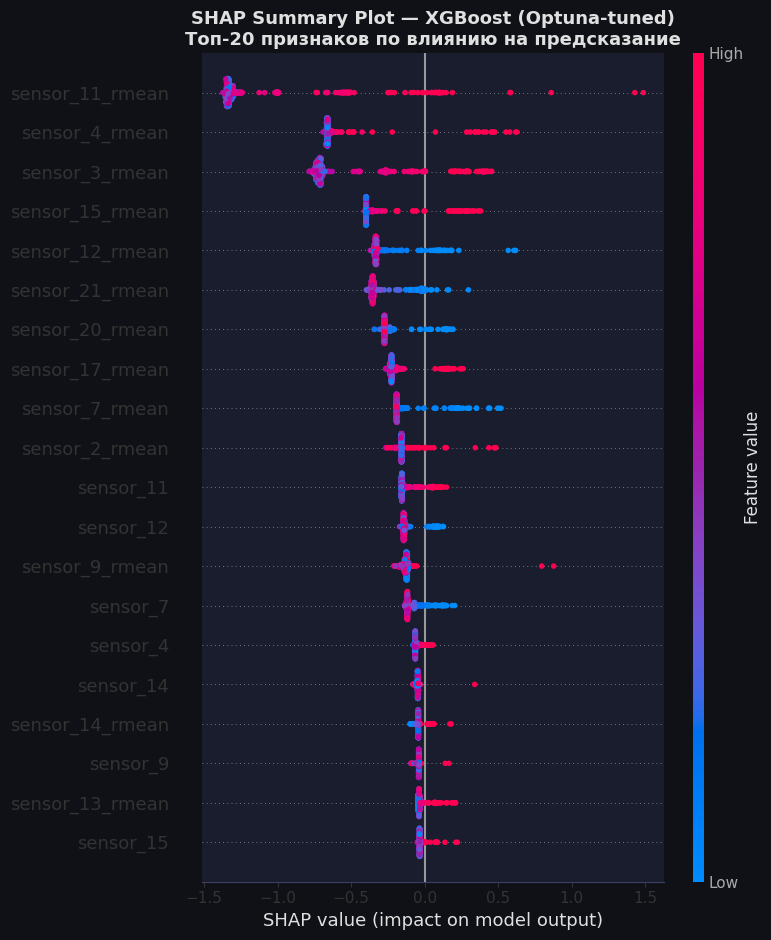

✅ SHAP Summary Plot сохранён: shap_summary.png


In [20]:
import shap
shap.initjs()  # инициализация JS для интерактивных графиков в ноутбуке


np.random.seed(42)
shap_sample_size = min(500, len(X_test_sc))
shap_idx = np.random.choice(len(X_test_sc), shap_sample_size, replace=False)
X_shap = X_test_sc[shap_idx]

explainer   = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_shap)

print(f'✅ SHAP-значения вычислены для {shap_sample_size} примеров')
print(f'   shap_values shape: {shap_values.shape}')

# ─────────────────────────────────────────────
# SHAP Summary Plot
# ─────────────────────────────────────────────
plt.figure(figsize=(12, 9))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_cols,
    max_display=20,    # показываем топ-20 признаков
    show=False,
    plot_type='dot'    # «beeswarm» визуализация
)
plt.title('SHAP Summary Plot — XGBoost (Optuna-tuned)\nТоп-20 признаков по влиянию на предсказание',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SHAP Summary Plot сохранён: shap_summary.png')

In [21]:
# ─────────────────────────────────────────────
# Анализ: какие датчики сигнализируют о поломке?
# ─────────────────────────────────────────────
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_cols
).sort_values(ascending=False)

print('🔍 Топ-10 признаков по среднему |SHAP| (влияние на предсказание поломки):')
print('─' * 55)
for i, (feat, val) in enumerate(mean_abs_shap.head(10).items(), 1):
    bar = '█' * int(val / mean_abs_shap.max() * 25)
    print(f'{i:2d}. {feat:35s} {val:.4f}  {bar}')

print('\n📌 Интерпретация:')
top1 = mean_abs_shap.index[0]
top2 = mean_abs_shap.index[1]
print(f'   Признак [{top1}] — наибольший вклад в предсказание.')
print(f'   Признак [{top2}] — второй по значимости.')
print('   Суффикс "_rmean" означает rolling mean (тренд),')
print('   суффикс "_rstd" означает rolling std (нестабильность).')

🔍 Топ-10 признаков по среднему |SHAP| (влияние на предсказание поломки):
───────────────────────────────────────────────────────
 1. sensor_11_rmean                     1.2057  █████████████████████████
 2. sensor_4_rmean                      0.6451  █████████████
 3. sensor_3_rmean                      0.6275  █████████████
 4. sensor_15_rmean                     0.3767  ███████
 5. sensor_12_rmean                     0.3171  ██████
 6. sensor_21_rmean                     0.2922  ██████
 7. sensor_20_rmean                     0.2568  █████
 8. sensor_17_rmean                     0.2177  ████
 9. sensor_7_rmean                      0.1906  ███
10. sensor_2_rmean                      0.1579  ███

📌 Интерпретация:
   Признак [sensor_11_rmean] — наибольший вклад в предсказание.
   Признак [sensor_4_rmean] — второй по значимости.
   Суффикс "_rmean" означает rolling mean (тренд),
   суффикс "_rstd" означает rolling std (нестабильность).


### 🔍 Интерпретация SHAP-графика

**SHAP Summary Plot** читается следующим образом:

- **Признаки вверху** — оказывают наибольшее влияние на предсказание (высокий |SHAP|)
- **Красные точки** (высокое значение признака) **справа** → высокое значение датчика **увеличивает вероятность поломки**
- **Синие точки** (низкое значение признака) **слева** → низкое значение датчика **снижает вероятность поломки**

**Что сигнализирует о надвигающейся поломке:**

1. **Rolling mean датчиков** — скользящее среднее по 5 циклам показывает устойчивый тренд к критическим значениям
2. **Rolling std датчиков** — рост нестабильности (дрожание показаний) часто предшествует поломке
3. **Датчики температуры и давления** (sensor_9, sensor_14) — отражают тепловое и механическое состояние двигателя



In [22]:
import gradio as gr
import numpy as np
import pandas as pd

# ─────────────────────────────────────────────
# Определяем ключевые датчики для UI
# Берём топ-8 из SHAP-анализа, только оригинальные (без rolling)
# ─────────────────────────────────────────────
top_shap_sensors = mean_abs_shap.index[
    mean_abs_shap.index.isin(sensor_cols)
].tolist()[:8]

# Если SHAP-анализ не дал достаточно, дополняем топ-3 по корреляции
if len(top_shap_sensors) < 4:
    top_shap_sensors = top3_sensors[:4]

print(f'Датчики в Gradio UI: {top_shap_sensors}')

# Диапазоны значений датчиков из тренировочных данных
sensor_ranges = {
    s: (float(train_df[s].min()), float(train_df[s].max()),
        float(train_df[s].mean()))
    for s in top_shap_sensors
}

# ─────────────────────────────────────────────
# Функция предсказания для Gradio
# ─────────────────────────────────────────────
def predict_failure_risk(*sensor_values):
    """
    Принимает значения ключевых датчиков от пользователя,
    заполняет остальные признаки средними значениями из трейна,
    возвращает риск поломки.
    """
    # Создаём строку признаков, заполненную средними значениями
    input_dict = {col: train_df[col].mean() for col in feature_cols}

    # Перезаписываем введённые датчики
    for sensor, value in zip(top_shap_sensors, sensor_values):
        input_dict[sensor] = value
        # Обновляем rolling mean и std этого датчика (упрощённо: используем само значение)
        if f'{sensor}_rmean' in input_dict:
            input_dict[f'{sensor}_rmean'] = value
        if f'{sensor}_rstd' in input_dict:
            input_dict[f'{sensor}_rstd'] = 0.0

    # Формируем вектор признаков в правильном порядке
    input_row = np.array([[input_dict[c] for c in feature_cols]], dtype=np.float32)
    input_scaled = scaler.transform(input_row)

    # Предсказание
    prob = xgb_tuned.predict_proba(input_scaled)[0][1]
    risk_pct = prob * 100

    # Формируем читаемый вывод
    if risk_pct >= 70:
        level = '🔴 ВЫСОКИЙ РИСК — Срочное ТО рекомендовано!'
        color = '#FF4444'
    elif risk_pct >= 40:
        level = '🟡 СРЕДНИЙ РИСК — Усиленный мониторинг'
        color = '#FFB347'
    else:
        level = '🟢 НИЗКИЙ РИСК — Двигатель в норме'
        color = '#A8FF78'

    result_text = (
        f"Вероятность поломки в ближайшие 30 циклов: {risk_pct:.1f}%\n\n"
        f"{level}\n\n"
        f"Рекомендация:\n"
        f"{'  ⚠️  Немедленно направить на плановый осмотр!' if risk_pct >= 70 else '  ✅  Продолжить нормальную эксплуатацию'}"
    )
    return result_text


# ─────────────────────────────────────────────
# Строим Gradio-интерфейс
# ─────────────────────────────────────────────
with gr.Blocks(
    title='🔧 Predictive Maintenance — Turbofan Engine',
    theme=gr.themes.Soft(primary_hue='blue')
) as demo:

    gr.Markdown("""
    # 🔧 Predictive Maintenance Dashboard
    ### NASA Turbofan Engine — Риск поломки в ближайшие 30 циклов

    Введите текущие показания ключевых датчиков двигателя.
    Модель (XGBoost + Optuna) предскажет вероятность поломки.
    """)

    with gr.Row():
        with gr.Column(scale=2):
            gr.Markdown('### 📡 Показания датчиков')
            sliders = []
            for sensor in top_shap_sensors:
                s_min, s_max, s_mean = sensor_ranges[sensor]
                s = gr.Slider(
                    minimum=round(s_min, 2),
                    maximum=round(s_max, 2),
                    value=round(s_mean, 2),
                    step=round((s_max - s_min) / 200, 3),
                    label=f'📊 {sensor}  (норма: {s_mean:.2f})',
                    interactive=True
                )
                sliders.append(s)

        with gr.Column(scale=1):
            gr.Markdown('### 🎯 Результат диагностики')
            output_box = gr.Textbox(
                label='Оценка риска',
                lines=8,
                interactive=False,
                placeholder='Введите показания датчиков и нажмите «Диагностика»'
            )
            predict_btn = gr.Button(
                '🔍 Запустить диагностику',
                variant='primary',
                size='lg'
            )

    predict_btn.click(
        fn=predict_failure_risk,
        inputs=sliders,
        outputs=output_box
    )

    gr.Markdown("""
    ---
    **Примечание:** Модель обучена на датасете FD001 (1 режим работы, 1 тип неисправности).
    Для других условий эксплуатации требуется отдельная модель.
    """)

# ─────────────────────────────────────────────
# Запуск: inline=True для Jupyter/Colab,
# share=True создаёт публичный URL
# ─────────────────────────────────────────────
print('🚀 Запускаем Gradio UI...')
demo.launch(
    share=True,       # публичный URL (работает в Colab)
    inline=True,      # показать прямо в ячейке Jupyter
    quiet=True,
    height=700
)

Датчики в Gradio UI: ['sensor_11', 'sensor_12', 'sensor_7', 'sensor_4', 'sensor_14', 'sensor_9', 'sensor_15', 'sensor_2']
🚀 Запускаем Gradio UI...
* Running on public URL: https://111f9719ac31816e7b.gradio.live
